In [1]:
pip install pandas openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import pandas as pd

df = pd.read_csv("ED2022.csv", low_memory=False)

keep_cols = [
    "AGE", "AGER", "SEX",
    "RFV1", "RFV2", "RFV3",
    "ARREMS", "AMBTRANSFER",
    "ARRTIME", "WAITTIME",
    "IMMEDR",
    "TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT",
    "PAINSCALE",
    "ADMIT", "ADMITHOS", "OBSSTAY",
    "DIAG1",
    "LWBS", "LEFTAMA"
]

keep_cols = [c for c in keep_cols if c in df.columns]
df_small = df[keep_cols].copy()

df_small["ARRTIME"] = df_small["ARRTIME"].astype("Int64")
df_small["ARRTIME_STR"] = df_small["ARRTIME"].astype(str).str.replace("<NA>", "", regex=False).str.zfill(4)
df_small["arrival_hour"] = pd.to_numeric(df_small["ARRTIME_STR"].str[:2], errors="coerce")
df_small["arrival_minute"] = pd.to_numeric(df_small["ARRTIME_STR"].str[2:], errors="coerce")

df_small.to_csv("ED2022_parsed_small.csv", index=False)


RFV code explanation

| Range       | Category                      |
| ----------- | ----------------------------- |
| 10000–10999 | General symptoms              |
| 11000–11999 | Psychological symptoms        |
| 12000–12999 | Gastrointestinal symptoms     |
| 13000–13999 | Neurological symptoms         |
| 14000–14999 | Respiratory symptoms          |
| 15000–15999 | Cardiovascular symptoms       |
| 16000–16999 | Genitourinary symptoms        |
| 17000–17999 | Skin symptoms                 |
| 18000–18999 | Musculoskeletal symptoms      |
| 19000–19999 | Injuries / trauma             |
| 20000+      | Diagnostic tests / follow-ups |


In [3]:
df["BAC"]
df["BAC"].unique()

array([0, 1])

In [4]:
df_small.shape

(16025, 27)

In [5]:
df_small.head()

,AGE,AGER,SEX,RFV1,RFV2,RFV3,ARREMS,AMBTRANSFER,ARRTIME,WAITTIME,...,PAINSCALE,ADMIT,ADMITHOS,OBSSTAY,DIAG1,LWBS,LEFTAMA,ARRTIME_STR,arrival_hour,arrival_minute
0,23,2,1,15451,-9,-9,2,-7,604,10,...,-8,-7,0,-7,T833,0,0,0604,6,4
1,15,2,2,15250,15300,-9,-9,-9,1053,40,...,-9,-7,0,-7,K297,0,0,1053,10,53
2,19,2,2,12601,13050,12250,2,-7,1419,70,...,-8,-7,0,-7,R000,0,0,1419,14,19
3,0,1,2,14000,-9,-9,2,-7,1825,-7,...,-9,-7,0,-7,R059,0,0,1825,18,25
4,18,2,1,17600,16450,-9,2,-7,2243,14,...,-8,-7,0,-7,N898,0,0,2243,22,43


In [6]:
df_small = df_small[df_small["ADMIT"] >= 0]
df_small.count()

AGE               1811
AGER              1811
SEX               1811
RFV1              1811
RFV2              1811
RFV3              1811
ARREMS            1811
AMBTRANSFER       1811
ARRTIME           1811
WAITTIME          1811
IMMEDR            1811
TEMPF             1811
PULSE             1811
RESPR             1811
BPSYS             1811
BPDIAS            1811
POPCT             1811
PAINSCALE         1811
ADMIT             1811
ADMITHOS          1811
OBSSTAY           1811
DIAG1             1811
LWBS              1811
LEFTAMA           1811
ARRTIME_STR       1811
arrival_hour      1811
arrival_minute    1811
dtype: int64

<Axes: xlabel='arrival_hour'>

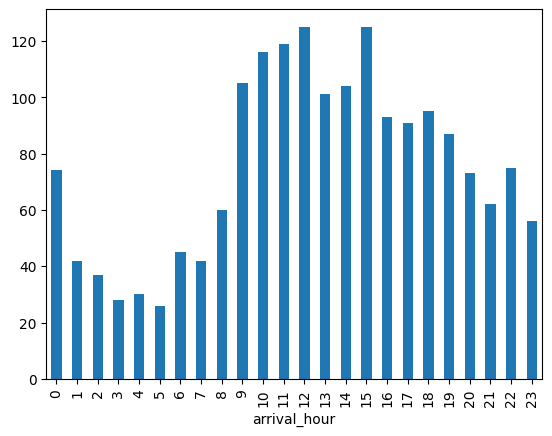

In [7]:
df_small.groupby("arrival_hour").size().plot(kind="bar")

(14561, 23)
   AGE  SEX  ARRTIME  WAITTIME    LOV  IMMEDR   RFV1  ARREMS  TEMPF  PULSE  \
0   23    1      604      10.0  228.0     3.0  15451       2  984.0   72.0   
1   15    2     1053      40.0  319.0     NaN  15250      -9  983.0   67.0   
2   19    2     1419      70.0  551.0     3.0  12601       2  987.0   79.0   
3    0    2     1825       NaN    NaN     NaN  14000       2  985.0  146.0   
4   18    1     2243      14.0  168.0     3.0  17600       2  986.0   97.0   

   ...  POPCT  PAINSCALE  ADMIT  OBSSTAY  LWBS  LEFTAMA  INJURY  SEEN72  \
0  ...   72.0        NaN    NaN      NaN   0.0      0.0     1.0     2.0   
1  ...   96.0        NaN    NaN      NaN   0.0      0.0     0.0     NaN   
2  ...   79.0        NaN    NaN      NaN   0.0      0.0     0.0     2.0   
3  ...   99.0        NaN    NaN      NaN   0.0      0.0     0.0     NaN   
4  ...  100.0        NaN    NaN      NaN   0.0      0.0     0.0     2.0   

   arrival_hour  arrival_minute  
0             6               4  


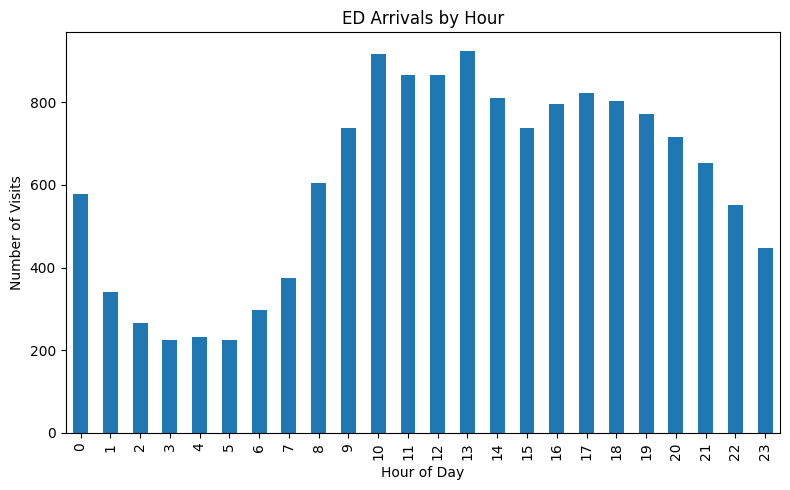

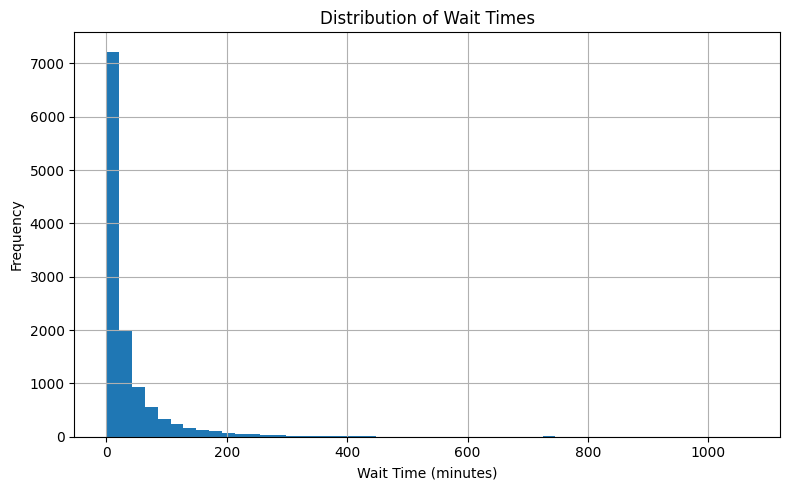

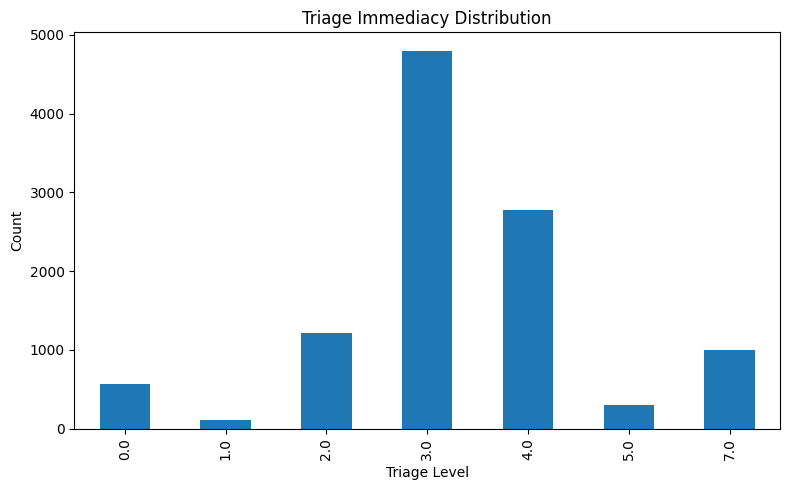

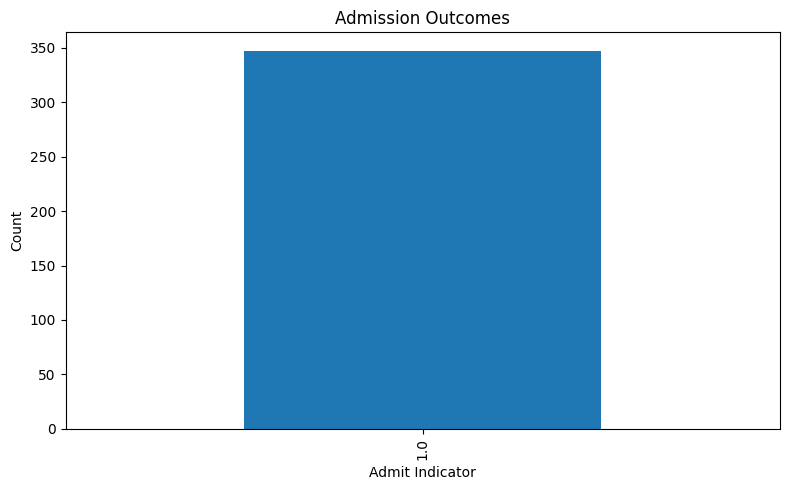

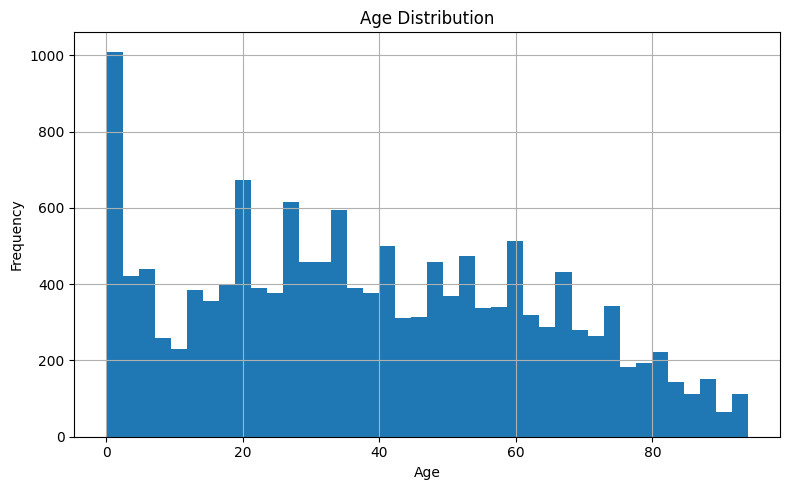


Admission rate by triage level:
IMMEDR
0.0    1.0
1.0    1.0
2.0    1.0
3.0    1.0
4.0    1.0
5.0    1.0
7.0    1.0
Name: ADMIT, dtype: float64


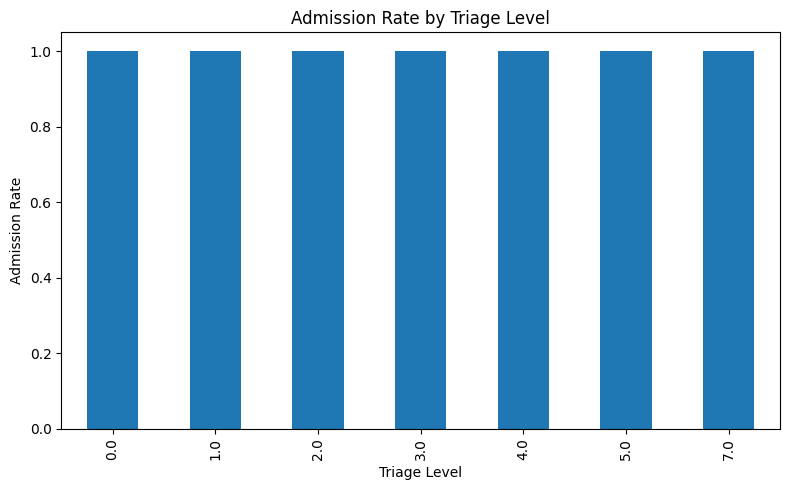


Admission rate by age group:
age_group
0-18     1.0
19-40    1.0
41-65    1.0
65+      1.0
Name: ADMIT, dtype: float64


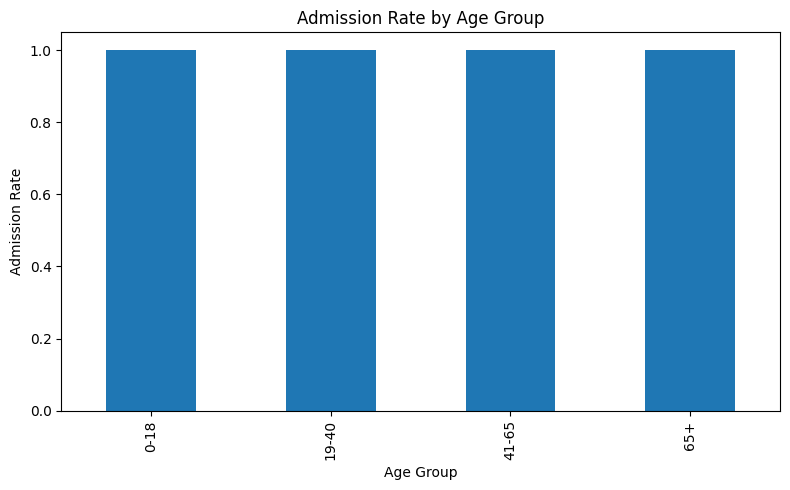


Median wait time by admission:
ADMIT
1.0    11.5
Name: WAITTIME, dtype: float64


<Figure size 800x500 with 0 Axes>

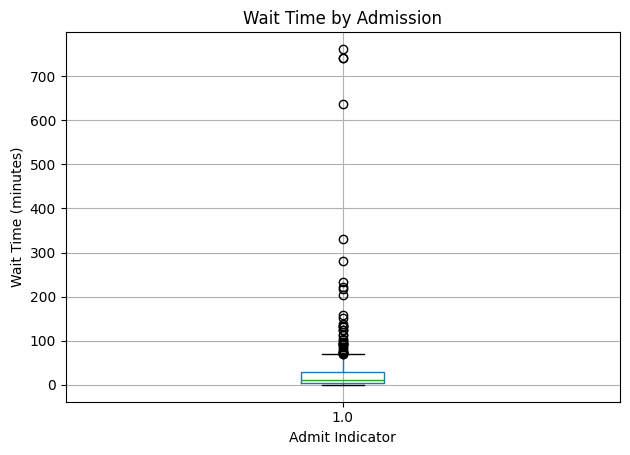


Sneaker patient rate:
0.14916557928713686

Sneaker patient rate by triage:
IMMEDR
0.0         0.0
1.0         0.0
2.0         0.0
3.0    0.325819
4.0    0.135563
5.0    0.125828
7.0       0.196
Name: sneaker_patient, dtype: Float64


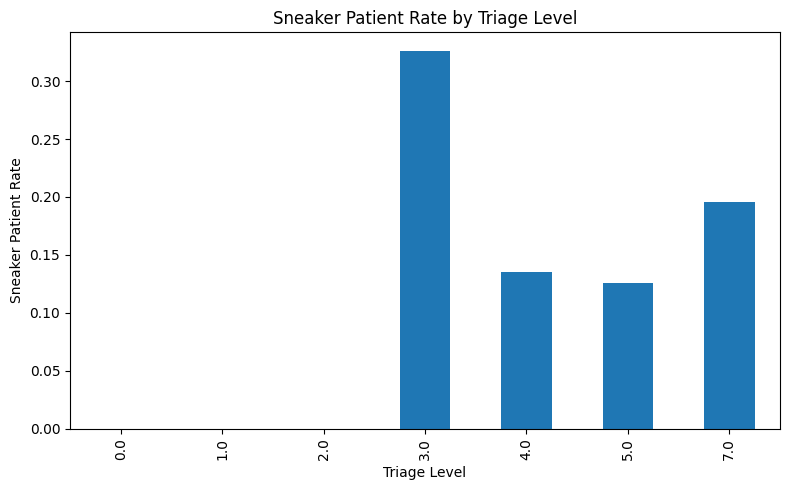


Top RFV1 codes among sneaker patients:
RFV1
15451    236
10501    103
12100     73
14150     60
19051     58
15300     51
15452     50
19201     47
10552     45
12250     45
Name: count, dtype: int64


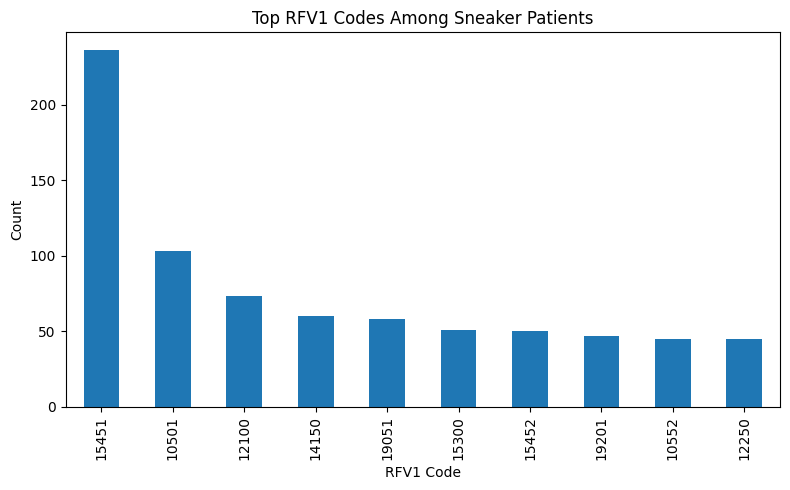

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv("ED2022.csv", low_memory=False)

# -----------------------------
# 2. Keep useful columns
# -----------------------------
cols = [
    "AGE", "SEX", "ARRTIME", "WAITTIME", "LOV",
    "IMMEDR", "RFV1", "ARREMS",
    "TEMPF", "PULSE", "RESPR", "BPSYS", "BPDIAS", "POPCT", "PAINSCALE",
    "ADMIT", "OBSSTAY", "LWBS", "LEFTAMA", "INJURY", "SEEN72"
]

cols = [c for c in cols if c in df.columns]
df_small = df[cols].copy()

# -----------------------------
# 3. Parse arrival hour
# -----------------------------
df_small["ARRTIME"] = pd.to_numeric(df_small["ARRTIME"], errors="coerce")
arr = (
    df_small["ARRTIME"]
    .astype("Int64")
    .astype(str)
    .str.replace("<NA>", "", regex=False)
    .str.zfill(4)
)

df_small["arrival_hour"] = pd.to_numeric(arr.str[:2], errors="coerce")
df_small["arrival_minute"] = pd.to_numeric(arr.str[2:], errors="coerce")

# -----------------------------
# 4. Clean common NHAMCS missing codes
# -----------------------------
clean_cols = [
    "WAITTIME", "LOV", "IMMEDR", "TEMPF", "PULSE", "RESPR",
    "BPSYS", "BPDIAS", "POPCT", "PAINSCALE", "ADMIT",
    "OBSSTAY", "LWBS", "LEFTAMA", "INJURY", "SEEN72"
]

for c in clean_cols:
    if c in df_small.columns:
        df_small[c] = pd.to_numeric(df_small[c], errors="coerce")
        df_small.loc[df_small[c] < 0, c] = pd.NA

# optional stricter cleaning for admission
if "ADMIT" in df_small.columns:
    df_small = df_small[df_small["ADMIT"].isin([0, 1]) | df_small["ADMIT"].isna()]

# -----------------------------
# 5. Basic summaries
# -----------------------------
print(df_small.shape)
print(df_small.head())
print(df_small.describe(include="all"))

# -----------------------------
# 6. Plot: arrivals by hour
# -----------------------------
plt.figure(figsize=(8, 5))
df_small["arrival_hour"].value_counts().sort_index().plot(kind="bar")
plt.title("ED Arrivals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Visits")
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Plot: wait time distribution
# -----------------------------
plt.figure(figsize=(8, 5))
df_small["WAITTIME"].dropna().hist(bins=50)
plt.title("Distribution of Wait Times")
plt.xlabel("Wait Time (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Plot: triage immediacy distribution
# -----------------------------
plt.figure(figsize=(8, 5))
df_small["IMMEDR"].dropna().value_counts().sort_index().plot(kind="bar")
plt.title("Triage Immediacy Distribution")
plt.xlabel("Triage Level")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Plot: admission outcomes
# -----------------------------
plt.figure(figsize=(8, 5))
df_small["ADMIT"].dropna().value_counts().sort_index().plot(kind="bar")
plt.title("Admission Outcomes")
plt.xlabel("Admit Indicator")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. Plot: age distribution
# -----------------------------
plt.figure(figsize=(8, 5))
df_small["AGE"].dropna().hist(bins=40)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Admission rate by triage level
# -----------------------------
if "IMMEDR" in df_small.columns and "ADMIT" in df_small.columns:
    admit_by_triage = df_small.groupby("IMMEDR")["ADMIT"].mean()
    print("\nAdmission rate by triage level:")
    print(admit_by_triage)

    plt.figure(figsize=(8, 5))
    admit_by_triage.plot(kind="bar")
    plt.title("Admission Rate by Triage Level")
    plt.xlabel("Triage Level")
    plt.ylabel("Admission Rate")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 12. Admission rate by age group
# -----------------------------
if "AGE" in df_small.columns and "ADMIT" in df_small.columns:
    df_small["age_group"] = pd.cut(
        df_small["AGE"],
        bins=[0, 18, 40, 65, 100],
        labels=["0-18", "19-40", "41-65", "65+"],
        include_lowest=True
    )

    admit_by_age = df_small.groupby("age_group")["ADMIT"].mean()
    print("\nAdmission rate by age group:")
    print(admit_by_age)

    plt.figure(figsize=(8, 5))
    admit_by_age.plot(kind="bar")
    plt.title("Admission Rate by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Admission Rate")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 13. Wait time by admission
# -----------------------------
if "WAITTIME" in df_small.columns and "ADMIT" in df_small.columns:
    print("\nMedian wait time by admission:")
    print(df_small.groupby("ADMIT")["WAITTIME"].median())

    plt.figure(figsize=(8, 5))
    df_small.boxplot(column="WAITTIME", by="ADMIT")
    plt.title("Wait Time by Admission")
    plt.suptitle("")
    plt.xlabel("Admit Indicator")
    plt.ylabel("Wait Time (minutes)")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 14. Create sneaker-patient flag
#    low-acuity / normal-ish vitals at arrival
#    but admitted or observation or very long visit
# -----------------------------
low_acuity = (
    (df_small["IMMEDR"] >= 3) &
    (df_small["POPCT"] >= 94) &
    (df_small["BPSYS"] >= 90) &
    (df_small["PULSE"].between(60, 110, inclusive="both")) &
    (df_small["RESPR"] <= 22)
)

severe_outcome = (
    (df_small["ADMIT"] == 1) |
    (df_small["OBSSTAY"] == 1) |
    (df_small["LOV"] > 240)
)

df_small["sneaker_patient"] = (low_acuity & severe_outcome).astype("Int64")

print("\nSneaker patient rate:")
print(df_small["sneaker_patient"].mean())

# -----------------------------
# 15. Sneaker patients by triage
# -----------------------------
sneaker_by_triage = df_small.groupby("IMMEDR")["sneaker_patient"].mean()
print("\nSneaker patient rate by triage:")
print(sneaker_by_triage)

plt.figure(figsize=(8, 5))
sneaker_by_triage.plot(kind="bar")
plt.title("Sneaker Patient Rate by Triage Level")
plt.xlabel("Triage Level")
plt.ylabel("Sneaker Patient Rate")
plt.tight_layout()
plt.show()

# -----------------------------
# 16. Top RFV1 codes among sneaker patients
# -----------------------------
top_sneaker_rfv = df_small.loc[df_small["sneaker_patient"] == 1, "RFV1"].value_counts().head(10)
print("\nTop RFV1 codes among sneaker patients:")
print(top_sneaker_rfv)

plt.figure(figsize=(8, 5))
top_sneaker_rfv.plot(kind="bar")
plt.title("Top RFV1 Codes Among Sneaker Patients")
plt.xlabel("RFV1 Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

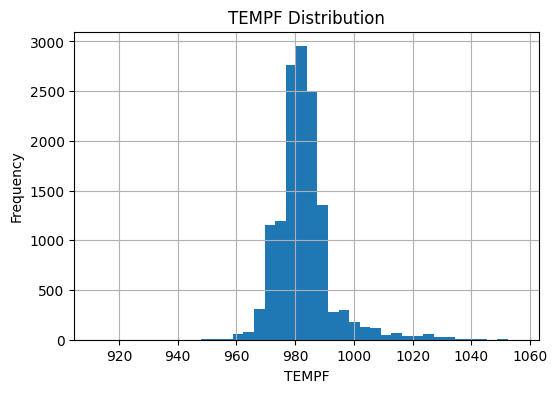

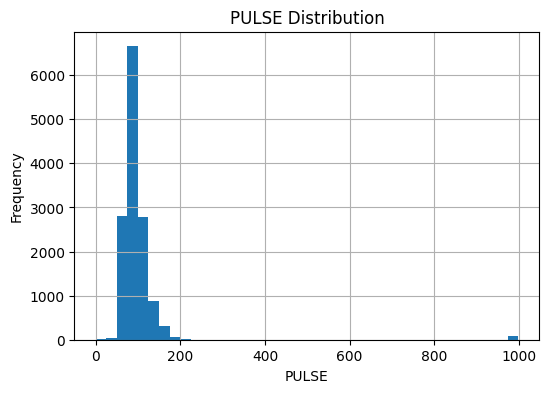

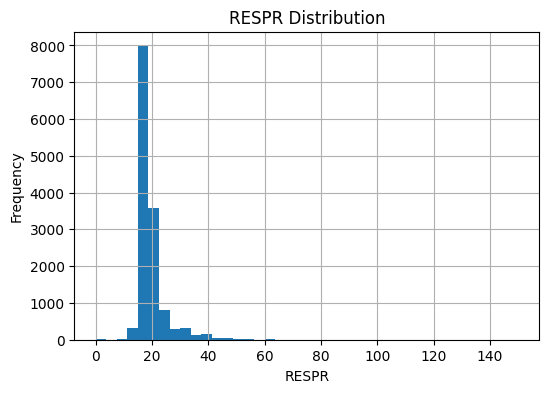

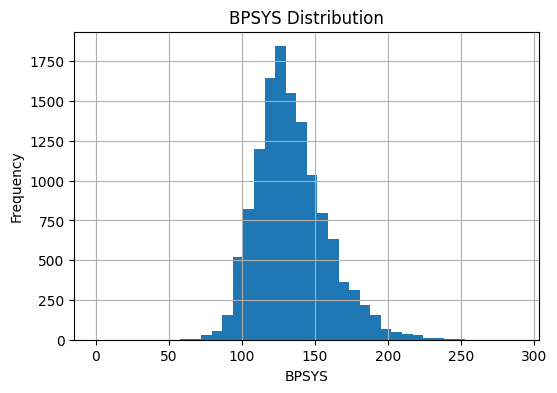

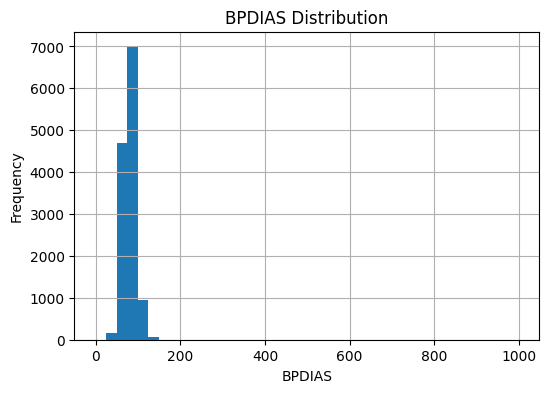

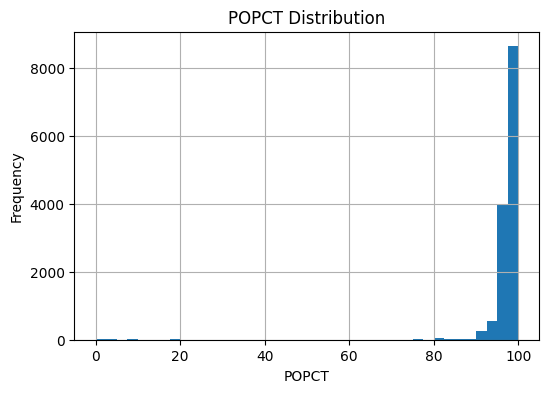

In [9]:
vitals = ["TEMPF","PULSE","RESPR","BPSYS","BPDIAS","POPCT"]

for v in vitals:
    
    plt.figure(figsize=(6,4))
    
    df_small[v].dropna().hist(bins=40)
    
    plt.title(f"{v} Distribution")
    plt.xlabel(v)
    plt.ylabel("Frequency")
    
    plt.show()

In [10]:
import pandas as pd
import numpy as np

df = pd.read_csv("ED2022.csv", low_memory=False)

# convert everything numeric if possible
df = df.apply(pd.to_numeric, errors="coerce")

# replace NHAMCS missing codes
df = df.replace([-7, -8, -9], np.nan)

# keep rows with known admission
df = df[df["ADMITHOS"].isin([0,1])]

# binary outcome
df["admit_binary"] = df["ADMITHOS"]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/var/folders/1m/5nsmtnrd1q35fs00r7595vw00000gn/T/ipykernel_63523/1137116878.py", line 10, in <module>
    df = df.replace([-7, -8, -9], np.nan)
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/generic.py", line 7812, in replace
    new_data = self._mgr.replace_list(
        src_list=to_replace,
    ...<2 lines>...
        regex=regex,
    )
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/internals/managers.py", line 527, in replace_list
    bm = self.apply(
        "replace_list",
    ...<3 lines>...
        regex=regex,
    )
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/pyth

In [ ]:
df = df[df["ADMITHOS"].isin([0,1])]

df["admit_binary"] = df["ADMITHOS"]

In [ ]:
arrival_features = [
    # visit timing / context available at arrival
    "VMONTH",
    "VDAYR",
    "ARRTIME",

    # demographics / baseline patient info
    "AGE",
    "AGER",
    "AGEDAYS",
    "SEX",
    "ETHUN",
    "ETHIM",
    "RACEUN",
    "RACER",
    "RACERETH",
    "RESIDNCE",

    # arrival mode / access / insurance
    "ARREMS",
    "AMBTRANSFER",
    "NOPAY",
    "PAYPRIV",
    "PAYMCARE",
    "PAYMCAID",
    "PAYWKCMP",
    "PAYSELF",
    "PAYNOCHG",
    "PAYOTH",
    "PAYDK",
    "PAYTYPER",

    # initial triage vitals
    "TEMPF",
    "PULSE",
    "RESPR",
    "BPSYS",
    "BPDIAS",
    "POPCT",
    "IMMEDR",
    "PAINSCALE",

    # recent utilization / reason for visit / episode
    "SEEN72",
    "RFV1",
    "RFV2",
    "RFV3",
    "RFV4",
    "RFV5",
    "RFV13D",
    "RFV23D",
    "RFV33D",
    "RFV43D",
    "RFV53D",
    "EPISODE",

    # injury / poisoning / intent / cause fields known from triage history
    "INJURY",
    "INJPOISAD",
    "INJURY72",
    "INTENT15",
    "INJURY_ENC",
    "CAUSE1",
    "CAUSE2",
    "CAUSE3",

    # chronic conditions / baseline history
    "NUMCHRON",
    "TOTCHRON",
    "HTN",
    "HYPERLIPID",
    "CHF",
    "CAD",
    "ANGINA",
    "MIHX",
    "STROKE",
    "DIABETES",
    "COPD",
    "ASTHMA",
    "CKD",
    "ESRD",
    "OSA",
    "OBESITY",
    "DEPRESSION",
    "SUBSTABUSE",
    "ALZHD",
    "DEMENTIA",
    "HISTORY",

    # pregnancy / social factors / mental health / substance use screens
    "PREGTEST",
    "PREGNANT",
    "ALCOHOL",
    "BAC",
    "ETOHAB",
    "DRUGAB",
    "DMP",
    "NODISP",
    "PSYCH",
    "VIOLENCE",

    # arrival triage / immediate disposition-related pre-eval context
    "TRIAGE",
    "DOA"
]

arrival_features = [c for c in arrival_features if c in df.columns]

In [ ]:
arrival_features = [c for c in arrival_features if c in df.columns]

df_model = df[arrival_features + ["admit_binary"]].copy()

print(df_model.shape)
print(df_model.head())

(16025, 70)
   VMONTH  VDAYR  ARRTIME  AGE  AGER  AGEDAYS  SEX  ETHUN  ETHIM  RACEUN  ...  \
0       9      2    604.0   23     2      NaN    1    2.0      2     1.0  ...   
1       9      2   1053.0   15     2      NaN    2    2.0      2     3.0  ...   
2       9      2   1419.0   19     2      NaN    2    1.0      1     NaN  ...   
3       9      2   1825.0    0     1    298.0    2    1.0      1     NaN  ...   
4       9      2   2243.0   18     2      NaN    1    2.0      2     1.0  ...   

   ESRD  OSA  OBESITY  ALZHD  PREGTEST  BAC  ETOHAB  NODISP  DOA  admit_binary  
0     0    0        0      0         0    0       0       0    0             0  
1     0    0        0      0         0    0       0       0    0             0  
2     0    0        0      0         0    0       0       0    0             0  
3     0    0        0      0         0    0       0       1    0             0  
4     0    0        0      0         1    0       0       0    0             0  

[5 rows x 70 c

In [ ]:
corr = df_model.corr()["admit_binary"].abs()

corr = corr.drop("admit_binary")

top_features = corr.sort_values(ascending=False)

print(top_features.head(20))

TOTCHRON       0.314038
AGE            0.256138
AGER           0.249643
ARREMS         0.248385
HTN            0.218334
CHF            0.204453
PAYMCARE       0.199382
CKD            0.187115
CAD            0.179547
COPD           0.152632
IMMEDR         0.148816
INJURY72       0.122846
AMBTRANSFER    0.117082
INTENT15       0.106761
OSA            0.102591
OBESITY        0.097140
ESRD           0.096182
ALZHD          0.094574
BAC            0.084604
INJPOISAD      0.080741
Name: admit_binary, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import itertools

# numeric predictors only
X = df_model.drop(columns=["admit_binary"]).select_dtypes(include=[np.number])
y = df_model["admit_binary"]

results = []

# iterate through all feature pairs
for f1, f2 in itertools.combinations(X.columns, 2):
    
    # multiplication interaction
    interaction = X[f1] * X[f2]
    
    corr = interaction.corr(y)
    
    results.append({
        "feature1": f1,
        "feature2": f2,
        "interaction": f"{f1} * {f2}",
        "correlation": corr
    })

interaction_df = pd.DataFrame(results)

# absolute correlation ranking
interaction_df["abs_corr"] = interaction_df["correlation"].abs()

interaction_df = interaction_df.sort_values("abs_corr", ascending=False)

print("Top interaction predictors:\n")
print(interaction_df.head(30))

/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/and

Top interaction predictors:

         feature1   feature2             interaction  correlation  abs_corr
250           AGE   TOTCHRON          AGE * TOTCHRON     0.334160  0.334160
314          AGER   TOTCHRON         AGER * TOTCHRON     0.331707  0.331707
1510        RESPR   TOTCHRON        RESPR * TOTCHRON     0.328939  0.328939
2099    INJPOISAD   TOTCHRON    INJPOISAD * TOTCHRON     0.318247  0.318247
1427        TEMPF   TOTCHRON        TEMPF * TOTCHRON     0.314608  0.314608
1627        POPCT   TOTCHRON        POPCT * TOTCHRON     0.312934  0.312934
1735       SEEN72   TOTCHRON       SEEN72 * TOTCHRON     0.311496  0.311496
560         ETHIM   TOTCHRON        ETHIM * TOTCHRON     0.307386  0.307386
500         ETHUN   TOTCHRON        ETHUN * TOTCHRON     0.305226  0.305226
439           SEX   TOTCHRON          SEX * TOTCHRON     0.300255  0.300255
2140     INTENT15   TOTCHRON     INTENT15 * TOTCHRON     0.296176  0.296176
1469        PULSE   TOTCHRON        PULSE * TOTCHRON     0.

/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/and

In [ ]:
import itertools
import numpy as np
import pandas as pd

# numeric predictors only
X = df_model.drop(columns=["admit_binary"]).select_dtypes(include=[np.number]).copy()
y = df_model["admit_binary"].copy()

# drop useless columns first
X = X.dropna(axis=1, how="all")
X = X.loc[:, X.nunique(dropna=True) > 1]

results = []

for f1, f2, f3 in itertools.combinations(X.columns, 3):
    interaction = X[f1] * X[f2] * X[f3]

    # skip all-missing or constant interaction columns
    if interaction.isna().all():
        continue
    if interaction.nunique(dropna=True) <= 1:
        continue

    corr = interaction.corr(y)

    if pd.isna(corr):
        continue

    results.append({
        "feature1": f1,
        "feature2": f2,
        "feature3": f3,
        "interaction": f"{f1} * {f2} * {f3}",
        "correlation": corr,
        "abs_corr": abs(corr)
    })

interaction3_df = pd.DataFrame(results).sort_values("abs_corr", ascending=False)

print("Top 30 three-feature interactions:\n")
print(interaction3_df.head(30))

/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/and

Top 30 three-feature interactions:

      feature1     feature2   feature3                        interaction  \
10367  AGEDAYS   INJURY_ENC   TOTCHRON    AGEDAYS * INJURY_ENC * TOTCHRON   
10363  AGEDAYS     INJURY72   TOTCHRON      AGEDAYS * INJURY72 * TOTCHRON   
9766   AGEDAYS  AMBTRANSFER  PAINSCALE  AGEDAYS * AMBTRANSFER * PAINSCALE   
10261  AGEDAYS         RFV4     ASTHMA            AGEDAYS * RFV4 * ASTHMA   
9771   AGEDAYS  AMBTRANSFER       RFV4       AGEDAYS * AMBTRANSFER * RFV4   
10151  AGEDAYS       IMMEDR     ASTHMA          AGEDAYS * IMMEDR * ASTHMA   
10103  AGEDAYS       BPDIAS   TOTCHRON        AGEDAYS * BPDIAS * TOTCHRON   
6936       AGE        RESPR   TOTCHRON             AGE * RESPR * TOTCHRON   
8705      AGER        RESPR   TOTCHRON            AGER * RESPR * TOTCHRON   
7468       AGE    INJPOISAD   TOTCHRON         AGE * INJPOISAD * TOTCHRON   
10104  AGEDAYS       BPDIAS     ASTHMA          AGEDAYS * BPDIAS * ASTHMA   
10079  AGEDAYS        BPSYS   TOTCHRON  

In [ ]:
import itertools
import numpy as np
import pandas as pd

# numeric predictors only
X = df_model.drop(columns=["admit_binary"]).select_dtypes(include=[np.number]).copy()
y = df_model["admit_binary"].copy()

# drop useless columns first
X = X.dropna(axis=1, how="all")
X = X.loc[:, X.nunique(dropna=True) > 1]

results = []

for f1, f2, f3, f4 in itertools.combinations(X.columns, 4):
    interaction = X[f1] * X[f2] * X[f3] * X[f4]

    # skip all-missing or constant interaction columns
    if interaction.isna().all():
        continue
    if interaction.nunique(dropna=True) <= 1:
        continue

    corr = interaction.corr(y)

    if pd.isna(corr):
        continue

    results.append({
        "feature1": f1,
        "feature2": f2,
        "feature3": f3,
        "feature4": f4,
        "interaction": f"{f1} * {f2} * {f3} * {f4}",
        "correlation": corr,
        "abs_corr": abs(corr)
    })

interaction4_df = pd.DataFrame(results).sort_values("abs_corr", ascending=False)

print("Top 30 four-feature interactions:\n")
print(interaction4_df.head(30))

/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/andersonlo/anaconda3/lib/python3.10/site-packages/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/and

Top 30 four-feature interactions:

       feature1     feature2     feature3    feature4  \
186393  AGEDAYS         RFV2   INJURY_ENC    TOTCHRON   
185814  AGEDAYS       IMMEDR     INJURY72    TOTCHRON   
181679  AGEDAYS  AMBTRANSFER        BPSYS        RFV4   
185818  AGEDAYS       IMMEDR   INJURY_ENC    TOTCHRON   
186389  AGEDAYS         RFV2     INJURY72    TOTCHRON   
181803  AGEDAYS  AMBTRANSFER         RFV2    INJURY72   
181700  AGEDAYS  AMBTRANSFER       BPDIAS        RFV4   
181581  AGEDAYS  AMBTRANSFER     PAYTYPER        RFV4   
175780  AGEDAYS          SEX  AMBTRANSFER        RFV4   
181805  AGEDAYS  AMBTRANSFER         RFV2  INJURY_ENC   
181804  AGEDAYS  AMBTRANSFER         RFV2    INTENT15   
179633  AGEDAYS     RACERETH  AMBTRANSFER        RFV4   
181824  AGEDAYS  AMBTRANSFER         RFV4      RFV43D   
44872     VDAYR      AGEDAYS  AMBTRANSFER        RFV4   
80097   ARRTIME      AGEDAYS  AMBTRANSFER        RFV4   
181749  AGEDAYS  AMBTRANSFER       IMMEDR    TOTCHRON